# **Series de tiempo**

En esta sesión, aprenderemos a utilizar la libreria de `prophet` de Python para realizar análisis de series temporales de manera automatizada. A través de un caso práctico dentro de una empresa, comprenderemos cómo aplicar las librerias para predecir ventas futuras y tomar decisiones estratégicas basadas en datos.

### Objetivos de Aprendizaje

- Comprender los conceptos básicos del análisis de series temporales.
- Aprender a utilizar las librerías [`prophet`](https://facebook.github.io/prophet/) y [`pmdarima`](https://pypi.org/project/pmdarima/) para modelado automatizado de series temporales.
- Aplicar técnicas de predicción para resolver un problema empresarial real.
- Interpretar los resultados y extraer insights accionables.

---

### **¿Qué son las series de tiempo?**

Secuencia de observaciones recolectadas a lo largo del tiempo, ordenadas cronológicamente.

- Temperatura diaria.
- Ventas mensuales de una tienda.
- Precios históricos del dólar.
- Señales fisiológicas (Electocardiograma, Electroencefalograma).
- Consumo de energía cada hora.

<p align="center">
  <img src="https://aprendeconeli.com/wp-content/uploads/2020/05/AdobeStock_300167162-scaled.jpeg" width="500"/>
</p>



### **Componentes de una serie de tiempo**

**1. Tendencia**  
Variación a largo plazo. Puede ser creciente, decreciente o constante.  
Ejemplo: el número de usuarios de internet global desde el año 2000.

No siempre está presente: algunas series son completamente planas o centradas alrededor de una media constante.

<p align="center">
  <img src="https://www.stackscale.com/wp-content/uploads/2023/05/Millones-usuarios-Internet-1995-2022-Stackscale.jpg" width="400"/>
</p>

**2. Estacionalidad**  
Patrones que se repiten en intervalos regulares (diarios, semanales, anuales...).  
Ejemplo: ventas de helados que suben en verano y bajan en invierno, mayor consumo eléctrico en verano.

No todas las series son estacionales: la actividad sísmica, por ejemplo, no tiene estacionalidad clara.

En el siguiente gráfico, que representa las ventas mensuales de refrescos, podemos visualizar claramente como se repite el mismo patrón año tras año: incremento sustancial de las ventas durante los meses de junio-julio, octubre y diciembre.

<p align="center">
  <img src="https://pablotenorio.com/wp-content/uploads/2019/02/Estacionalidad-Grafico-Ventas.jpg" width="400"/>
</p>

**3. Ciclo**  
Variaciones a largo plazo que no son regulares, pero muestran cierta periodicidad.   
Ej: Ciclos económicos.

No siempre es observable, y muchas veces es difícil de separar de la tendencia.

<p align="center">
  <img src="https://anatrenza.com/wp-content/uploads/2019/10/Ana-Trenza-Ciclos-Economicos-y-Fases.jpg" width="400"/>
</p>

**4. Ruido**  
Componentes aleatorios, no explicables por los anteriores.  
Ej: Errores de medición, eventos impredecibles.

#### **Ejemplo descomposición de la serie de tiempo**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Número de pasajeros aéreos internacionales entre 1949 y 1960.
# Cargar los datos
df = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv')
df.columns = ['date', 'y']
df['date'] = pd.to_datetime(df['date'])

df.head()


,date,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [7]:
sns.set_style('darkgrid')

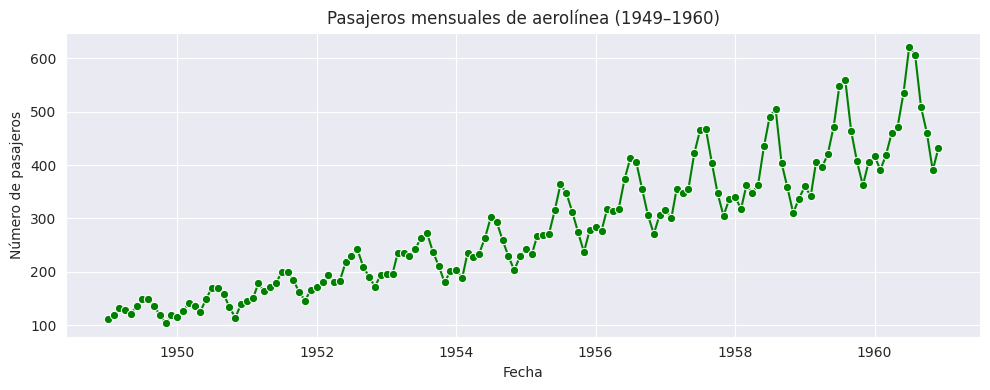

In [22]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='date', y='y', color='green', marker='o')
plt.title("Pasajeros mensuales de aerolínea (1949–1960)")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.grid(True)
plt.tight_layout()
plt.show()

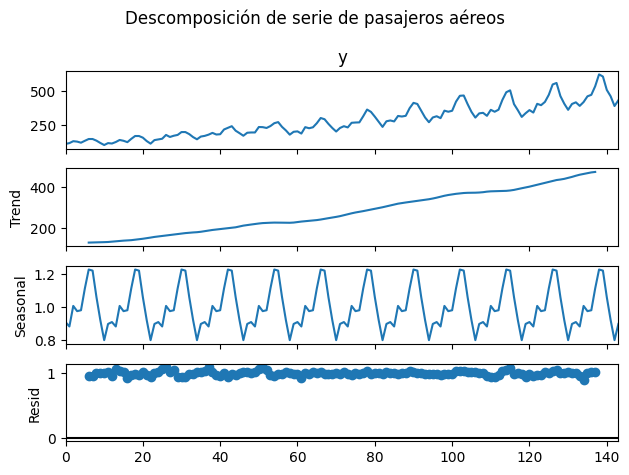

In [3]:
# Descomposición
decomposition = seasonal_decompose(df['y'], model='multiplicative', period=12)
decomposition.plot()
plt.suptitle("Descomposición de serie de pasajeros aéreos")
plt.tight_layout()
plt.show()

### **Serie estacionaria vs. no estacionaria**

<table>
  <thead>
    <tr>
      <th style="text-align:center;">Característica</th>
      <th style="text-align:center;">🟢 Series Estacionarias</th>
      <th style="text-align:center;">🔴 Series No Estacionarias</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align:center;"><strong>Media</strong></td>
      <td style="text-align:center;">Constante a lo largo del tiempo</td>
      <td style="text-align:center;">Cambia con el tiempo</td>
    </tr>
    <tr>
      <td style="text-align:center;"><strong>Varianza</strong></td>
      <td style="text-align:center;">Constante</td>
      <td style="text-align:center;">Variable</td>
    </tr>
    <tr>
      <td style="text-align:center;"><strong>Tendencia</strong></td>
      <td style="text-align:center;">No presente</td>
      <td style="text-align:center;">Puede tener tendencia creciente o decreciente</td>
    </tr>
    <tr>
      <td style="text-align:center;"><strong>Estacionalidad</strong></td>
      <td style="text-align:center;">No tiene patrones estacionales</td>
      <td style="text-align:center;">Puede tener estacionalidad regular</td>
    </tr>
    <tr>
      <td style="text-align:center;"><strong>Modelado con ARIMA clásico</strong></td>
      <td style="text-align:center;">Se puede aplicar directamente</td>
      <td style="text-align:center;">Requiere transformación (como diferenciación)</td>
    </tr>
    <tr>
      <td style="text-align:center;"><strong>Ejemplo típico</strong></td>
      <td style="text-align:center;">Ruido blanco</td>
      <td style="text-align:center;">Ventas mensuales con tendencia y estacionalidad</td>
    </tr>
    <tr>
      <td style="text-align:center;"><strong>Visualización</strong></td>
      <td style="text-align:center;">Fluctúa alrededor de una media constante</td>
      <td style="text-align:center;">Muestra cambios estructurales claros a lo largo del tiempo</td>
    </tr>
  </tbody>
</table>

<p align="center">
  <img src="https://estrategiastrading.com/wp-content/uploads/2016/12/media_estacionaria.png" width="500"/>
</p>


### **¿Por qué modelar series de tiempo?**

- **Predicción:** ¿Cuántas unidades se venderán el próximo mes?
- **Detección de anomalías:** ¿Hubo un consumo energético inusual?
- **Planeación:** Anticipar demanda y ajustar producción.
- **Análisis de impacto:** ¿Cómo afectó una campaña de marketing las ventas?

---


### **Caso Práctico: ForecastTech Inc.**

#### **Contexto de la Empresa**

RazerTech Inc. es una empresa dedicada a la fabricación y venta de dispositivos electrónicos. A lo largo de los últimos tres años, ha experimentado fluctuaciones en sus ventas mensuales debido a factores estacionales y tendencias del mercado.

#### **Problema Empresarial**

El departamento de finanzas necesita prever las ventas mensuales para el próximo año con el fin de:

- Optimizar la gestión del inventario.
- Planificar estrategias de marketing.
- Ajustar la producción y recursos.

#### Objetivo de la Sesión

Utilizar las paqueterías de para crear un modelo que prediga las ventas mensuales de RazerTech Inc. para el próximo año, y proporcionar recomendaciones basadas en el análisis.

---

#### Configuración del Entorno

Antes de comenzar, asegúrate de tener instalada la siguiente librería:

```bash
pip install prophet

In [1]:
!pip install prophet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 90.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 917.9/917.9 kB 95.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 27.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

/root/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### **Paso 1:** Importación de Librerías y Carga de Datos
Comenzamos importando las librerías necesarias y cargando el conjunto de datos proporcionado por la empresa.

In [10]:
df = pd.read_csv('./ventas_mensuales_MXN.csv', parse_dates=['Fecha'])
df.tail()

,Fecha,Ventas
115,2024-08-01,558330
116,2024-09-01,538180
117,2024-10-01,491540
118,2024-11-01,628780
119,2024-12-01,937600


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Fecha   120 non-null    datetime64[ns]
 1   Ventas  120 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.0 KB


In [7]:
df.describe()

,Fecha,Ventas
count,120,120.000000
mean,2019-12-16 10:48:00,433541.583333
min,2015-01-01 00:00:00,149950.000000
25%,2017-06-23 12:00:00,304010.000000
50%,2019-12-16 12:00:00,423500.000000
75%,2022-06-08 12:00:00,536920.000000
max,2024-12-01 00:00:00,937600.000000
std,NaN,162460.824718


#### **Paso 2:** Exploración y Visualización de los Datos
Antes de modelar, es importante entender la naturaleza de nuestros datos.

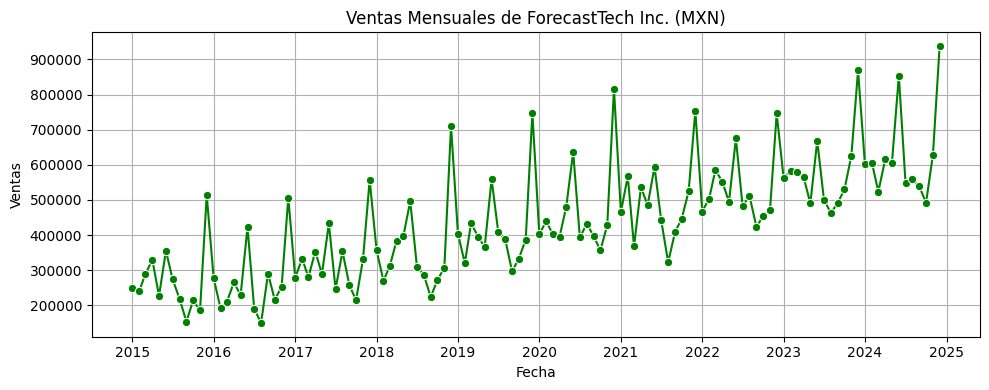

In [8]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='Fecha', y='Ventas', color='green', marker='o')
plt.title('Ventas Mensuales de ForecastTech Inc. (MXN)')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.tight_layout()
plt.show()

#### **Paso 3:** Train Test Split - Series de tiempo

Es una técnica para dividir los datos temporales en dos partes:

* **Entrenamiento (train):** donde el modelo aprende los patrones históricos.
* **Prueba (test):** donde evaluamos cómo se comporta el modelo con datos futuros no vistos.

**ES MUY IMPORTANTE EL ORDEN CRONOLÓGICO**

In [9]:
# Renombrar columnas como exige Prophet: ds = fecha, y = valor
df.rename({'Fecha':'ds', 'Ventas':'y'},axis=1,inplace=True)
df.head()

,ds,y
0,2015-01-01,249840
1,2015-02-01,239750
2,2015-03-01,289110
3,2015-04-01,329540
4,2015-05-01,226740


In [10]:
#Train 80% de los datos (Orden importa)
len(df)*.90,len(df)*.10

(108.0, 12.0)

In [11]:
train = df[:108]   # primeros 96 datos
test = df[108:]    # últimos 24 datos

len(train),len(test)

(108, 12)

In [12]:
train.tail()

,ds,y
103,2023-08-01,462800
104,2023-09-01,491520
105,2023-10-01,529840
106,2023-11-01,625610
107,2023-12-01,868390


In [13]:
test.head()

,ds,y
108,2024-01-01,600900
109,2024-02-01,605970
110,2024-03-01,523810
111,2024-04-01,615080
112,2024-05-01,604480


#### **Paso 4:** Configuración del Modelo Prophet

La librería se hará cargo del entrenamiento usando los datos.

In [14]:
# Crear y entrenar el modelo Prophet
modelo_prophet = Prophet()
modelo_prophet.fit(train)

00:54:51 - cmdstanpy - INFO - Chain [1] start processing
00:54:51 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
# Crear fechas futuras (periods = longitud del set de prueba)
future = modelo_prophet.make_future_dataframe(periods=len(test), freq='MS',include_history=False)
future.head()

,ds
0,2024-01-01
1,2024-02-01
2,2024-03-01
3,2024-04-01
4,2024-05-01


In [16]:
# Hacer predicciones
forecast = modelo_prophet.predict(future)

**Columnas reelevantes en la predicción**

* **ds**  
    * Es la fecha de la predicción (viene de la columna original 'Fecha').
* **yhat**  
    * Es la predicción puntual que hace Prophet para esa fecha.
* **yhat_lower**  
    * Es el límite inferior del intervalo de confianza (por defecto 80%).  
    * “El valor mínimo probable con un 80% de confianza”.
* **yhat_upper**  
    * Es el límite superior del intervalo de confianza.  
    * “El valor máximo probable con un 80% de confianza”.

In [17]:
# Seleccionar columnas relevantes
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2024-01-01,590659.279353,543714.059869,635865.784802
1,2024-02-01,543571.699114,500053.256649,594410.614026
2,2024-03-01,540886.356289,492892.580071,589548.287703
3,2024-04-01,609358.611686,564432.351805,659082.785472
4,2024-05-01,614694.556277,565342.614830,661259.051450


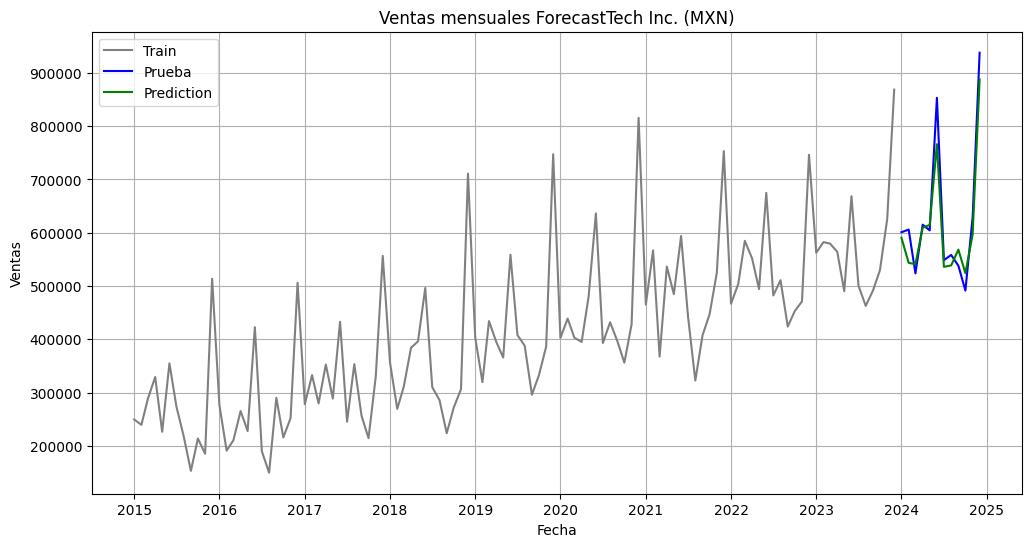

In [18]:
plt.figure(figsize=(12,6))
# Entrenamiento (Train) - Valores reales
plt.plot(train['ds'], train['y'], label='Train', color='gray')
# Prueba (Test) - Valores reales
plt.plot(test['ds'], test['y'], label='Prueba', color='blue')
# Predicción (Forecast) - Línea central
plt.plot(forecast['ds'], forecast['yhat'], label='Prediction', color='green')
# Título y etiquetas
plt.title('Ventas mensuales ForecastTech Inc. (MXN)')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

#### **Paso 5:** Evaluación del Modelo

Para saber qué tan bien está funcionando nuestro modelo, debemos comparar las predicciones con los valores reales del conjunto de prueba vs los datos reales.

**Evaluación visual**

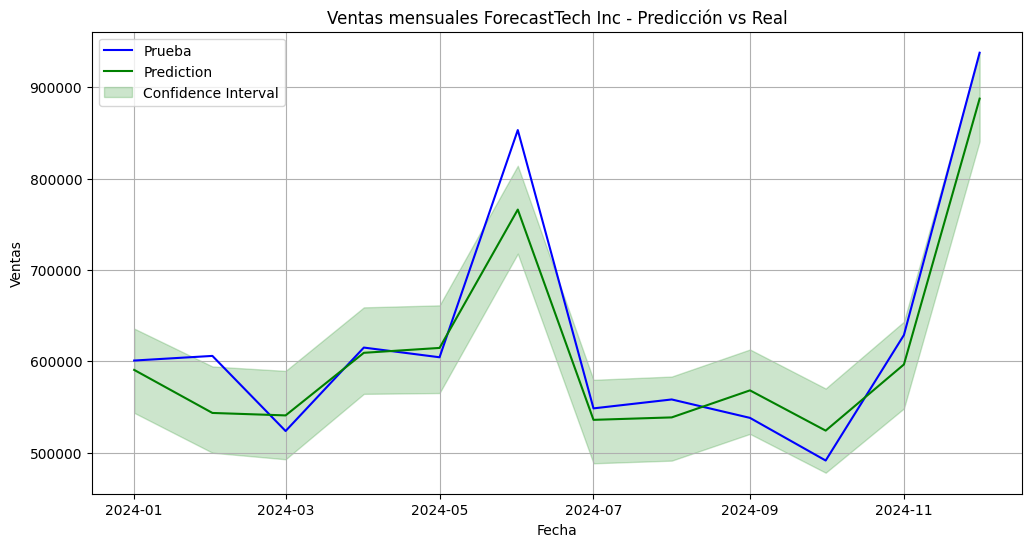

In [19]:
plt.figure(figsize=(12,6))
# Prueba (Test) - Valores reales
plt.plot(test['ds'], test['y'], label='Prueba', color='blue')
# Predicción (Forecast) - Línea central
plt.plot(forecast['ds'], forecast['yhat'], label='Prediction', color='green')
# Intervalo de confianza (shaded region)
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='green', alpha=0.2, label='Confidence Interval')
# Título y etiquetas
plt.title('Ventas mensuales ForecastTech Inc - Predicción vs Real')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()


**Métricas de evaluación**

1. **Error Absoluto Medio (MAE - Mean Absolute Error)**  
Mide la media de los errores absolutos entre las predicciones y los valores reales. Es intuitivo y fácil de entender.
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

2. **Error Cuadrático Medio (MSE - Mean Squared Error)**  
Mide el promedio de los errores al cuadrar las diferencias entre las predicciones y los valores reales.
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

3. **Raíz del Error Cuadrático Medio (RMSE - Root Mean Squared Error)**  
Es simplemente la raíz cuadrada del MSE y se presenta en las mismas unidades que los datos.
$$RMSE = \sqrt{MSE}$$

4. **Error Absoluto Medio Porcentual (MAPE - Mean Absolute Percentage Error)**
Mide el error en términos porcentuales. Es útil cuando quieres entender el error relativo de las predicciones.
$$MAPE = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100$$

In [20]:
y_true = np.array(test['y'])  # Valores reales
y_pred = np.array(forecast['yhat'])  # Valores predichos

# 1. MAE (Mean Absolute Error)
mae = mean_absolute_error(y_true, y_pred)
print(f"MAE: El error promedio de las predicciones es de {mae:.2f} MXN")

# 2. MSE (Mean Squared Error)
mse = mean_squared_error(y_true, y_pred)
print(f"MSE: Los errores cuadráticos promedio son {mse:.2f}")

# 3. RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse)
print(f"RMSE:  El error cuadrático promedio es de aproximadamente {rmse:.2f} MXN")

# 4. MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_true-y_pred)/y_true))*100
print(f"MAPE: El modelo tiene un error promedio de aproximadamente {mape:.2f}%")

MAE: El error promedio de las predicciones es de 30831.89 MXN
MSE: Los errores cuadráticos promedio son 1505409720.58
RMSE:  El error cuadrático promedio es de aproximadamente 38799.61 MXN
MAPE: El modelo tiene un error promedio de aproximadamente 4.72%


#### **Paso 6:** Predicción Futura

Una vez evaluado el modelo, lo utilizamos para hacer predicciones de los próximos 12 meses.

00:54:52 - cmdstanpy - INFO - Chain [1] start processing
00:54:52 - cmdstanpy - INFO - Chain [1] done processing


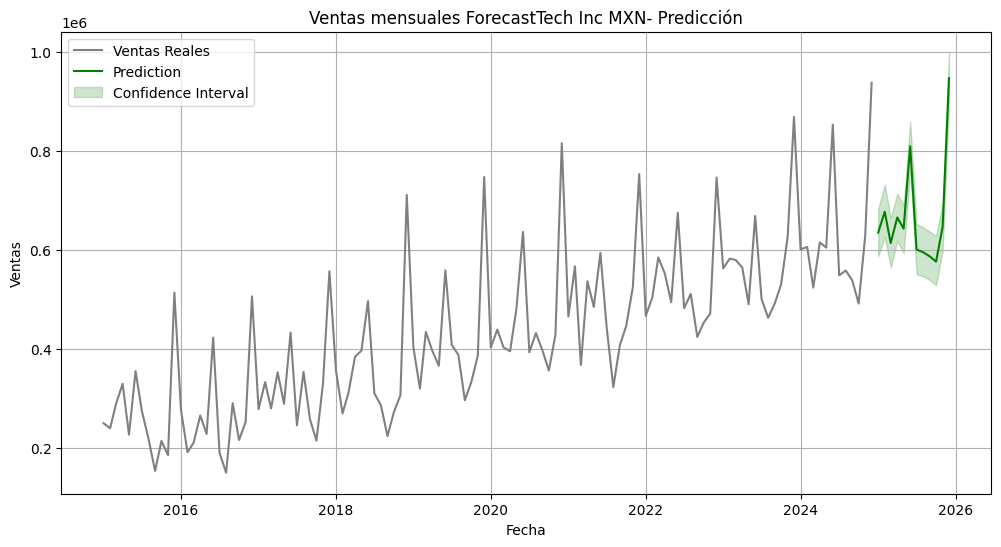

In [21]:
modelo_prophet_final = Prophet()
#Utilizamos todo el conjunto de datos
modelo_prophet_final.fit(df)

future_prophet = modelo_prophet_final.make_future_dataframe(periods=12, freq='MS',include_history=False)
forecast_future = modelo_prophet_final.predict(future_prophet)

plt.figure(figsize=(12,6))
# Valores reales
plt.plot(df['ds'], df['y'], label='Ventas Reales', color='gray')
# Predicción (Forecast) - Línea central
plt.plot(forecast_future['ds'], forecast_future['yhat'], label='Prediction', color='green')
# Intervalo de confianza (shaded region)
plt.fill_between(forecast_future['ds'], forecast_future['yhat_lower'], forecast_future['yhat_upper'], color='green', alpha=0.2, label='Confidence Interval')
# Título y etiquetas
plt.title('Ventas mensuales ForecastTech Inc MXN- Predicción')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

#### **Conclusión y Recomendaciones Estratégicas**
Una vez obtenidas las predicciones:

- Inventario: Aumentar producción en los meses con mayor demanda proyectada.

- Marketing: Realizar campañas específicas en los meses con ventas más bajas para compensar la caída.

- Finanzas: Ajustar flujo de efectivo y recursos de personal para meses clave.



<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=52d42f7b-e3e4-4fa6-bf85-d2691d7edf9a' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>